# contact-CLASP · clasp_l2 — the coevolution baseline (mean-field DCA)

The classical comparator: **direct coupling analysis**. Given a multiple-sequence alignment, co-evolving residue pairs usually touch in 3D. Here the MSA is *simulated* with covariation seeded from the true contacts (a stand-in for a real jackhmmer/hhblits alignment — that swap is the scale-up); mean-field DCA should then recover those pairs.

Metric again is **precision@L** against the same true contacts as clasp_l1.

In [1]:
import os, sys
ROOT = os.path.abspath("")
while ROOT != os.path.dirname(ROOT) and not os.path.isdir(os.path.join(ROOT, "common")):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)                          # for `import common`
sys.path.insert(0, os.path.join(ROOT, "clasp"))   # for `import clasp_common`
DATA = os.path.join(ROOT, "data")
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\xai-starter


In [2]:
from clasp_common import (load_demo_chain, simulate_msa, mfdca_contacts,
                          neff, precision_at_l)
seq, coords, true = load_demo_chain(cache_dir=DATA)
msa = simulate_msa(seq, true, n_seqs=500)
dca = mfdca_contacts(msa)
print('MSA:', msa.shape, ' Neff/L:', round(neff(msa)/len(seq), 2))
print('precision@L (DCA):', round(precision_at_l(dca, true), 3))

MSA: (500, 58)  Neff/L: 7.1
precision@L (DCA): 0.793


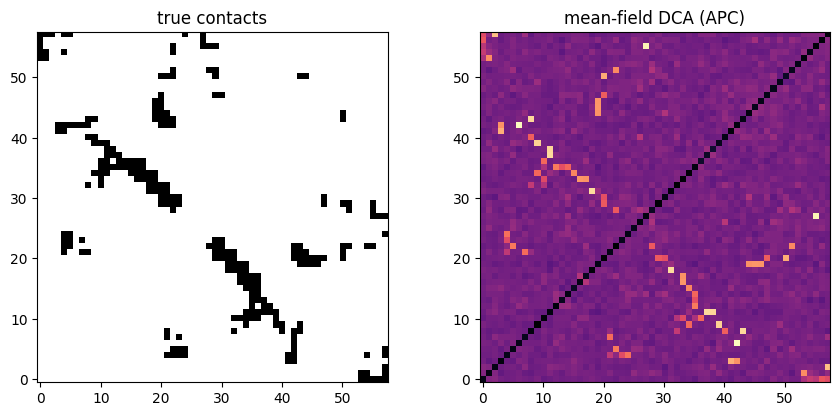

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].imshow(true, cmap='Greys', origin='lower'); ax[0].set_title('true contacts')
ax[1].imshow(dca, cmap='magma', origin='lower'); ax[1].set_title('mean-field DCA (APC)')
plt.tight_layout(); plt.show()

### Things to experiment with
- Lower `n_seqs` and `couple_p` in `simulate_msa` and watch DCA degrade.
- Swap in a **real** MSA (jackhmmer/hhblits) — the scale-up that makes this a real benchmark.